In [35]:
# # Celda creada por Juan para eliminar todos los checkpoints del anteriores. Cuidado, elimina el modelo actual
# import glob, os                                                                                                                                                                        
# for f in glob.glob(os.path.join("results/parte-4", '*.pth*')):                                                                                                                              
#     os.remove(f)                                                                                                                                                                       
#     print(f'Deleted: {f}')

### Code needed from previous cells

In [ ]:
import os
from tqdm import tqdm
import numpy as np
import torch
import torch.nn.functional as FT
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision.models.segmentation import deeplabv3_resnet101
import torchvision.transforms.functional as F
import cv2
import csv
import random
import matplotlib.pyplot as plt
# Set random seed for reproducibility
manualSeed = 999
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
# torch uses some non-deterministic algorithms
torch.backends.cudnn.enabled = False

from sklearn.metrics import roc_auc_score, jaccard_score
from sklearn.preprocessing import LabelBinarizer


def set_bn_eval(mm):
    """Set BatchNorm modules to eval mode to freeze running stats during training."""
    if isinstance(mm, torch.nn.modules.batchnorm._BatchNorm):
        mm.eval()


def train_model(model, criterion, dataloaders, device, optimizer, lr_scheduler, metrics, bpath, model_name, num_classes=5, num_epochs=3, aux_weight=0.0):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_jaccard = 0

    fieldnames = ['epoch', 'Train_loss', 'Val_loss'] + \
        [f'Train_{m}' for m in metrics.keys()] + \
        [f'Val_{m}' for m in metrics.keys()]

    with open(os.path.join(bpath, 'log.csv'), 'w', newline='') as csvfile:
        csv.DictWriter(csvfile, fieldnames=fieldnames).writeheader()

    lb = LabelBinarizer()
    lb.fit(range(num_classes))

    for epoch in range(1, num_epochs + 1):
        checkpoint_path = os.path.join(bpath, f'{model_name}-epoch{epoch}.pth')

        if os.path.exists(checkpoint_path):
            print(f"> Loading checkpoint for epoch {epoch}")
            checkpoint = torch.load(checkpoint_path, weights_only=False)
            model.load_state_dict(checkpoint['state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer'])
            lr_scheduler.load_state_dict(checkpoint['scheduler'])
            best_jaccard = checkpoint['best_jaccard']
            print(f"> Checkpoint loaded for epoch {epoch}")
            continue

        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        batchsummary = {a: [0] for a in fieldnames}

        for phase in ['Train', 'Val']:
            if phase == 'Train':
                model.train()
            else:
                model.eval()
            model.apply(set_bn_eval)
            epoch_loss = 0.0
            n_batches = 0

            for sample in tqdm(iter(dataloaders[phase])):
                inputs = sample['image'].to(device)
                masks = sample['mask'].to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'Train'):
                    outputs = model(inputs)
                    loss = criterion(outputs['out'], masks)
                    if aux_weight > 0.0 and outputs.get('aux') is not None:
                        loss = loss + aux_weight * criterion(outputs['aux'], masks)

                    y_pred = outputs['out']
                    y_prob = torch.nn.functional.softmax(y_pred, dim=1)
                    _, y_pred = torch.max(y_prob, dim=1)
                    y_pred = y_pred.data.cpu().numpy()

                    # Reshape prob tensor from (B, C, H, W) -> (C, B*H*W)
                    y_prob = np.reshape(
                        np.transpose(y_prob.data.cpu().numpy(), (1, 0, 2, 3)),
                        (num_classes, -1)
                    )
                    y_true = masks.data.cpu().numpy()

                    if num_classes == 2:
                        y_true = y_true > 0

                    for name, metric in metrics.items():
                        if name == 'jaccard_score':
                            ji = metric(y_true.ravel(), y_pred.ravel(), labels=np.unique(y_true), average=None)
                            # Skip all-background batches to avoid np.mean([]) warnings; np.nanmean handles the nan downstream
                            ji_fg = ji[1:]
                            batchsummary[f'{phase}_{name}'].append(np.mean(ji_fg) if len(ji_fg) > 0 else np.nan)
                    
                        else:  # roc_auc_score
                            if num_classes == 2:
                                batchsummary[f'{phase}_{name}'].append(
                                    metric(y_true[:, 1, :, :].ravel(), y_prob[1:, :].T,
                                           average='micro', multi_class='ovr')
                                )
                            else:
                                batchsummary[f'{phase}_{name}'].append(
                                    metric(lb.transform(y_true.ravel()), y_prob.T,
                                           average='micro', multi_class='ovr')
                                )

                    if phase == 'Train':
                        loss.backward()
                        optimizer.step()

                epoch_loss += loss.item()
                n_batches += 1

            batchsummary['epoch'] = epoch
            batchsummary[f'{phase}_loss'] = epoch_loss / max(n_batches, 1)
            print(f'{phase} Loss: {batchsummary[f"{phase}_loss"]:.4f}')

        for field in fieldnames[3:]:
            batchsummary[field] = np.nanmean(batchsummary[field])
        print(batchsummary)

        with open(os.path.join(bpath, 'log.csv'), 'a', newline='') as csvfile:
            csv.DictWriter(csvfile, fieldnames=fieldnames).writerow(batchsummary)

        if batchsummary['Val_jaccard_score'] >= best_jaccard:
            best_jaccard = batchsummary['Val_jaccard_score']
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({'state_dict': best_model_wts}, os.path.join(bpath, f'{model_name}_best.pth.tar'))

        if isinstance(lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            lr_scheduler.step(batchsummary['Val_jaccard_score'])
        else:
            lr_scheduler.step()

        torch.save({
            'epoch': epoch,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': lr_scheduler.state_dict(),
            'best_jaccard': best_jaccard,
        }, checkpoint_path)

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Highest Jaccard: {best_jaccard:.4f}')

    model.load_state_dict(best_model_wts)
    return model


data_dir = "myVOC4"
num_workers=8         # to debug, fix num_workers=0
img_size=512           # Size of the images
batchsize_train=1      # Batch size for training
batchsize_test=1       # Batch size for test (it must be one to generate predictions)
num_classes=5         # Number of classes
num_epochs =8
step_size=5
result_dir = 'results' # Result directory
# Detect if we have a GPU available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def get_deeplabv3(num_classes=1):
    model = deeplabv3_resnet101(pretrained=True, progress=True)
    model.classifier = DeepLabHead(2048, num_classes)
    return model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.colors as mcolors

def test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, SAVE_OPT, batch_size=1, rescale_input=True):
    cm_total = np.zeros((len(class_names), len(class_names)), dtype=np.int64)  # Fix: cm must be 2D
    jaccard = []

    # Set up result directory and CSV file
    os.makedirs(result_dir, exist_ok=True)
    csv_path = os.path.join(result_dir, 'results_multiclass.csv')
    if os.path.exists(csv_path):
        os.remove(csv_path)

    if SAVE_OPT:
        os.makedirs(os.path.join(result_dir, 'predictions_multiclass'), exist_ok=True)

    # --- CONFIGURACIÓN DE COLORES POR CLASE ---
    if num_classes <= 10:
        cmap_base = plt.get_cmap('tab10')
    elif num_classes <= 20:
        cmap_base = plt.get_cmap('tab20')
    else:
        cmap_base = plt.get_cmap('jet') 

    # FIX: Disitribución de colores normalizada
    colors_list = [cmap_base(i / max(num_classes - 1, 1)) for i in range(num_classes)]
    
    colors_list = [cmap_base(i) for i in range(num_classes)]
    colors_list[0] = (0, 0, 0, 1.0) # Negro para el fondo
    custom_cmap = mcolors.ListedColormap(colors_list)
    norm_bins = np.arange(num_classes + 1) - 0.5
    custom_norm = mcolors.BoundaryNorm(norm_bins, num_classes)
    # ---------------------------------------------

    with open(csv_path, 'w', newline='') as csv_file:
        coord_writer = csv.writer(csv_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)

        model.eval()
        for sample in tqdm(dataloaders['Test']):
            with torch.no_grad():
                inputs = sample['image'].to(device)
                masks = sample['mask'].to(device)

                y_prob = torch.nn.functional.softmax(model(inputs)['out'], dim=1)
                _, y_pred = torch.max(y_prob, dim=1)
                y_pred = y_pred.data.cpu().numpy()   # (B, H, W)
                y_true = masks.data.cpu().numpy()    # (B, H, W) — categorical, not one-hot

            for j in range(y_pred.shape[0]):
                img_name = os.path.basename(sample['img_path'][j])
                pred_j = y_pred[j]   # (H, W)
                true_j = y_true[j]   # (H, W)

                # Jaccard index per foreground class (excluding background at index 0)
                ji = np.zeros(num_classes - 1, dtype=float)
                for i in range(1, num_classes):
                    pred_i = pred_j == i
                    true_i = true_j == i
                    intersection = np.logical_and(pred_i, true_i).sum()
                    union = pred_i.sum() + true_i.sum() - intersection
                    ji[i - 1] = intersection / union if union > 0 else 0.0  # Fix: avoid division by zero
                jaccard.append(ji)

                # Confusion matrix — both arrays must be flat 1D
                cm_total += confusion_matrix(
                    true_j.ravel(), pred_j.ravel(),
                    labels=list(range(len(class_names)))  # Fix: ensure consistent label ordering
                )

                if SAVE_OPT:
                    n_fg   = num_classes - 1  # foreground classes (skip background)
                    n_rows = 1 + n_fg
                    fig, axes = plt.subplots(n_rows, 3,
                                             figsize=(15, 5 * n_rows),
                                             constrained_layout=True)
                    if n_rows == 1:
                        axes = axes[np.newaxis, :]  # ensure 2-D indexing

                    img_display = inputs[j].permute(1,2,0).cpu().numpy()
                    if rescale_input:
                        lo, hi = img_display.min(), img_display.max()
                        img_display = (img_display - lo) / (hi - lo + 1e-8)

                    # ── Row 0: overview (original | GT multiclass | Pred multiclass) ──
                    axes[0, 0].imshow(img_display)
                    axes[0, 0].set_title('Imagen Original', fontsize=11)
                    axes[0, 0].axis('off')

                    axes[0, 1].imshow(true_j, cmap=custom_cmap, norm=custom_norm, interpolation='nearest')
                    axes[0, 1].set_title('GT (multiclass)', fontsize=11)
                    axes[0, 1].axis('off')

                    axes[0, 2].imshow(pred_j, cmap=custom_cmap, norm=custom_norm, interpolation='nearest')
                    axes[0, 2].set_title('Pred (multiclass)', fontsize=11)
                    axes[0, 2].axis('off')

                    # Legend patches on the overview row
                    import matplotlib.patches as mpatches
                    patches = [mpatches.Patch(color=colors_list[ci],
                                              label=class_names[ci])
                               for ci in range(num_classes)]
                    axes[0, 2].legend(handles=patches, fontsize=7,
                                      loc='lower right', framealpha=0.7)

                    # ── Rows 1+: per-class binary (GT | Pred) ─────────────────────────
                    for ri, ci in enumerate(range(1, num_classes), start=1):
                        color = colors_list[ci]
                        cname = class_names[ci]

                        gt_bin   = (true_j == ci).astype(float)
                        pred_bin = (pred_j == ci).astype(float)

                        # Tinted binary: class color where mask=1, black where 0
                        def tint(binary, rgb):
                            img = np.zeros((*binary.shape, 3))
                            img[binary == 1] = rgb[:3]
                            return img

                        axes[ri, 0].imshow(img_display)
                        axes[ri, 0].set_title(f'{cname}', fontsize=11)
                        axes[ri, 0].axis('off')

                        axes[ri, 1].imshow(tint(gt_bin, color))
                        axes[ri, 1].set_title(f'GT: {cname}', fontsize=11)
                        axes[ri, 1].axis('off')

                        axes[ri, 2].imshow(tint(pred_bin, color))
                        axes[ri, 2].set_title(f'Pred: {cname}', fontsize=11)
                        axes[ri, 2].axis('off')

                    save_path = os.path.join(result_dir, 'predictions_multiclass', img_name[:-4] + '.png')
                    plt.savefig(save_path, dpi=120, bbox_inches='tight', pad_inches=0.1)
                    plt.close(fig)

                coord_writer.writerow([img_name, str(ji)])

        mean_jaccard = np.mean(jaccard, axis=0)
        coord_writer.writerow(['MEAN', str(mean_jaccard)])

    print(f'Jaccard index per class: {mean_jaccard}')

    # --- VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN (PORCENTUAL) ---
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. Cálculo de proporciones
    row_sums = cm_total.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.divide(
        cm_total.astype(float), 
        row_sums, 
        out=np.zeros_like(cm_total, dtype=float), 
        where=row_sums != 0
    )
    
    # 2. Convertir a porcentaje y REDONDEAR explícitamente a 2 decimales
    cm_percentage = np.round(cm_normalized * 100.0, 2)
    
    # 3. Crear el display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=class_names)
    
    # 4. Graficar forzando formato y reduciendo tamaño de fuente de los números (text_kw)
    disp.plot(
        cmap='Blues', 
        values_format='.2f', 
        ax=ax, 
        xticks_rotation=45,
        text_kw={"fontsize": 8}  # <--- Esto evita que los números grandes solapen la celda
    )
    
    plt.title('Matriz de Confusión Acumulada Normalizada por Fila (%)')
    plt.tight_layout()
    
    cm_save_path = os.path.join(result_dir, 'confusion_matrix.png')
    plt.savefig(cm_save_path, dpi=300)
    plt.show()
    #plt.close(fig)
    # ------------------------------------------------------------
    
    return cm_total

Random Seed:  999


## [!] Parte 4. Trabajo autónomo del estudiante para la realización del proyecto

## Segmentación semántica de edificios afectados por desastres naturales

De este proyecto (si se elige) surge la segunda evaluación para la asignatura. Una vez comprendidos los fundamentos de la segmentación semántica con DeepLab-V3, el proyecto consistirá en realizar experimentos dirigidos a:

- Aplicar la segmentación semántica multi-clase al problema de evaluación del impacto de desastres naturales del primer proyecto, prediciendo para cada píxel de la imagen si pertenece al fondo, o a un edificio con alguno de los cuatro niveles de daño.
- Analizar los resultados y proporcionar estrategias de mejora sobre la arquitectura, el proceso de entrenamiento o la función de pérdida.

#### Detalles de la base de datos xBD

xBD es uno de los conjuntos de datos de evaluación de daños en edificios más grandes hasta la fecha. Contiene imágenes de alta resolución (menos de 0.8 m de GSD) que cubren 19 desastres naturales diferentes en todo el mundo (terremotos, inundaciones, incendios forestales, huracanes y tsunamis).

Para la segmentación semántica, cada imagen de 1024×1024 píxeles se acompaña de una **máscara de segmentación** a nivel de píxel con las siguientes clases:

| Valor en máscara | Significado |
|---|---|
| 0 | Fondo (*background*) |
| 1 | Edificio sin daño (*no-damage*) |
| 2 | Daño menor (*minor-damage*) |
| 3 | Daño mayor (*major-damage*) |
| 4 | Destruido (*destroyed*) |

### 4.1 Configuración

Cargue las librerías necesarias. Nótese que la mayor parte del código de entrenamiento y evaluación de las partes anteriores se puede reutilizar.

In [37]:
import os
import glob
import json
import tifffile
from tqdm import tqdm
import numpy as np
import copy
import time
import torch
import torch.nn.functional as FT
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision.models.segmentation import deeplabv3_resnet101
from torchvision import transforms, utils
import torchvision.transforms.functional as F
from PIL import Image, ImageFile, ImageDraw
import cv2
import csv
import random
import matplotlib.pyplot as plt
from shapely.wkt import loads
from shapely.geometry import Polygon
from collections import defaultdict
from natsort import natsorted
from tqdm import tqdm
# Set random seed for reproducibility
manualSeed = 999
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
# torch uses some non-deterministic algorithms
torch.backends.cudnn.enabled = False

Random Seed:  999


### 4.2 Dataset xBD adaptado para segmentación de imágenes

A diferencia del Proyecto 1, donde el dataset devolvía un *parche centrado en un edificio* junto con su etiqueta de daño (tarea de clasificación), aquí necesitamos adaptar la clase `xBDDataset` para la tarea de **segmentación de imágenes**. Para ello, el dataset debe devolver, para cada imagen (o ventana de imagen), una máscara de segmentación semántica donde los píxeles de cada edificio aparezcan anotados con una etiqueta de daño.

La máscara devuelta es un `LongTensor` de forma `[H, W]` con valores enteros de 0 a 4.

Usaremos la clase `xBDDataset` mejorada del Proyecto 1 (modo `task="segmentation"`) como punto de partida.

In [38]:
"""
xBDDataset — Dataset de PyTorch mejorado para el uso de la base de datos xBD para la evaluación
del impacto de desastres naturales sobre zonas urbanas, utilizando imágenes satelitales.

Mejoras clave respecto a la clase original:
  • El parámetro task= controla qué devuelve __getitem__ para que la misma clase funcione
    en clasificación, detección de objetos y segmentación).
  • La estrategia de muestreo se elige automáticamente por tarea:

      Todas las tareas    →  patch_size >= IMAGE_SIZE : una muestra por par de imágenes
                             pre-/post-desastre (modo de imagen completa, 
                             todos los edificios incluidos).

      classification      →  patch_size <  IMAGE_SIZE : una muestra por edificio.
                             El patch se centra en el centroide de la bbox de cada edificio
                             y se ajusta a los límites de la imagen. Sin duplicados,
                             sin ventanas vacías. Coincide exactamente con el código original.

      segmentation /      →  patch_size <  IMAGE_SIZE : ventanas ancladas a edificios.
      detection /            Se centra una ventana candidata en el centroide de cada edificio
                             (misma lógica de patch centrado o _centred_window que arriba).
                             Las ventanas casi duplicadas cuyos orígenes (superior-izquierda) estén
                             a una distancia menor o igual a `stride` píxeles entre sí, se fusionan
                             en una sola, conservando la primera en orden raster. El
                             conjunto de ventanas resultante es único, nunca está vacío y
                             cubre cada edificio al menos una vez.
                             stride=0  : una ventana por edificio (sin fusión).
                             stride=ps : des-duplicación gruesa similar a una cuadrícula,
                                         anclada a las posiciones de los edificios.
  • Anotaciones de cajas delimitadoras (bounding-boxes) en estilo COCO / Pascal-VOC 
  [x1,y1,x2,y2] para detección de edificios.
"""

# ──────────────────────────────────────────────────────────────────────────────
# Dataset
# ──────────────────────────────────────────────────────────────────────────────
eps = 1e-6  # numerical stability in _normalise

DAMAGE_CLASSES = {
    "no-damage":    0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed":    3,
}

TASKS = {"classification", "detection", "segmentation"}

IMAGE_SIZE = 1024  # xBD images are always 1024×1024

class xBDDataset(Dataset):
    """
    Parámetros
    ----------
    data_dir   : raíz del dataset xBD (contiene subdirectorios train/, val/, test/)
    split      : lista de subdirectorios a cargar, ej. ['train'] o ['val','test']
    task       : uno de 'classification' | 'segmentation' | 'detection'
    transform  : función para aplicar data augmentation aleatorio
    patch_size : longitud del lado (px) del patch cuadrado devuelto por muestra.
                 • classification  – patch centrado en el centroide de la bbox de cada edificio;
                   cualquier tamaño funciona, el valor por defecto 64 coincide con el código original.
                 • otras tareas     – usa IMAGE_SIZE (1024) para modo de imagen completa o
                   cualquier valor menor para modo de cuadrícula de ventana deslizante.
    stride     : radio de fusión (píxeles) para des-duplicar ventanas ancladas a edificios
                 (solo tareas que no son de clasificación). Dos ventanas candidatas cuyos
                 orígenes superior-izquierda estén dentro del stride en ambos ejes se fusionan.
    stats      : dict con claves 'mean' y 'std' (np.float32, forma [3]) para
                 normalización por canal. Si es None, las imágenes se escalan a [0, 1]
                 dividiendo por 255.
    max_size   : Número máximo de muestras a utilizar. Útil para depuración (debugging).
    """
    def __init__(
        self,
        data_dir: str,
        split: list[str] | None = None,
        task: str = "classification",
        transform: None = None,
        patch_size: int = 64,
        stride: int | None = None,
        stats: dict | None = None,
        max_size: int = 0,
    ):
        if split is None:
            split = ["train"]
        assert task in TASKS, f"task must be one of {TASKS}, got '{task}'"

        self.data_dir   = data_dir
        self.split      = split          # kept as list throughout
        self.task       = task
        self.transform  = transform
        self.max_size = max_size
        self.patch_size = patch_size
        self.stride     = stride if stride is not None else patch_size
        self.stats      = stats          # {'mean': np.array([R,G,B]),
                                         #  'std':  np.array([R,G,B])}

        # ------------------------------------------------------------------
        # Collect file paths
        # ------------------------------------------------------------------
        self.image_pre_files  = []
        self.image_post_files = []
        self.label_pre_files  = []
        self.label_post_files = []

        for s in split:
            split_dir = os.path.join(data_dir, s)
            for d in sorted(os.listdir(split_dir)):
                if not os.path.isdir(os.path.join(split_dir, d)):
                    continue
                img_dir = os.path.join(split_dir, d, "images")
                lbl_dir = os.path.join(split_dir, d, "labels")
                imgs  = os.listdir(img_dir)
                lbls  = os.listdir(lbl_dir)
                self.image_pre_files.append(
                    natsorted([os.path.join(img_dir, f) for f in imgs if "pre"  in f]))
                self.image_post_files.append(
                    natsorted([os.path.join(img_dir, f) for f in imgs if "post" in f]))
                self.label_pre_files.append(
                    natsorted([os.path.join(lbl_dir, f) for f in lbls if "pre"  in f]))
                self.label_post_files.append(
                    natsorted([os.path.join(lbl_dir, f) for f in lbls if "post" in f]))

        self.image_pre_files  = natsorted(np.hstack(self.image_pre_files))
        self.image_post_files = natsorted(np.hstack(self.image_post_files))
        self.label_pre_files  = natsorted(np.hstack(self.label_pre_files))
        self.label_post_files = natsorted(np.hstack(self.label_post_files))

        if self.max_size > 0:
            new_dataset_size = self.max_size
            idx = np.random.RandomState(seed=42).permutation(range(len(self.image_pre_files)))
            self.image_pre_files = np.array(self.image_pre_files)[idx[0:new_dataset_size]]
            self.image_post_files = np.array(self.image_post_files)[idx[0:new_dataset_size]]
            self.label_pre_files = np.array(self.label_pre_files)[idx[0:new_dataset_size]]
            self.label_post_files = np.array(self.label_post_files)[idx[0:new_dataset_size]]

        # ------------------------------------------------------------------
        # Build the sample list (patch-size-aware, no duplicates)
        # ------------------------------------------------------------------
        self.samples = []   # list of dicts, one per unique patch location
        self._build_samples()
        self._print_class_distribution()

    # ──────────────────────────────────────────────────────────────────────
    # Internal helpers
    # ──────────────────────────────────────────────────────────────────────
    @staticmethod
    def _load_json(path: str) -> dict:
        with open(path, "r") as f:
            return json.load(f)

    @staticmethod
    def _read_image(path: str) -> np.ndarray:
        img = tifffile.imread(path)
        if img.shape[:2] != (IMAGE_SIZE, IMAGE_SIZE):
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        return img

    def _parse_buildings(self, data_post: dict) -> list[dict]:
        """
        Devuelve una lista de dicts, cada uno con:
            wkt, label, bbox_full=[x1,y1,x2,y2]
        """
        buildings = []
        for feat in data_post.get("features", {}).get("xy", []):
            props = feat.get("properties", {})
            if props.get("feature_type") != "building":
                continue
            wkt  = feat.get("wkt", "")
            dmg  = props.get("subtype", "no-damage")
            if dmg not in DAMAGE_CLASSES and dmg != -1:
                continue
            try:
                geom = loads(wkt)
                if not (isinstance(geom, Polygon) and geom.is_valid):
                    continue
                coords = np.array(geom.exterior.coords, dtype=np.float32)
                x1, y1 = coords.min(axis=0)
                x2, y2 = coords.max(axis=0)
                buildings.append({
                    "wkt":       wkt,
                    "label":     DAMAGE_CLASSES[dmg] if dmg in DAMAGE_CLASSES else -1,
                    "bbox_full": [float(x1), float(y1), float(x2), float(y2)],
                })
            except Exception:
                continue
        return buildings

    # ------------------------------------------------------------------
    # Sample enumeration
    # ------------------------------------------------------------------
    @staticmethod
    def _centred_window(cx: float, cy: float, ps: int) -> tuple[int, int, int, int]:
        """
        Devuelve una ventana (x1, y1, x2, y2) de tamaño ps×ps centrada en (cx, cy),
        ajustada (clamped) para que la ventana nunca exceda los límites de la imagen.
        """
        half = ps // 2
        x1 = int(np.clip(round(cx) - half, 0, IMAGE_SIZE - ps))
        y1 = int(np.clip(round(cy) - half, 0, IMAGE_SIZE - ps))
        return x1, y1, x1 + ps, y1 + ps

    @staticmethod
    def _dedup_windows(
        origins: list[tuple[int, int]],
        stride:  int,
    ) -> list[tuple[int, int]]:
        """
        Elimina orígenes de ventanas que sean casi duplicados.

        Dos orígenes (x1, y1) y (x2, y2) se consideran duplicados cuando
            |x1 - x2| <= stride  Y  |y1 - y2| <= stride.

        El algoritmo recorre la lista de candidatos en orden raster (de arriba a abajo,
        de izquierda a derecha). Cuando un nuevo origen está a menos de `stride` píxeles
        de cualquier origen ya aceptado en ambos ejes, se descarta; de lo contrario,
        se acepta.

        stride=0  →  sin des-duplicación; se mantienen todos los candidatos.
        """
        if stride == 0 or not origins:
            return origins

        accepted: list[tuple[int, int]] = []
        for ox, oy in origins:
            too_close = any(
                abs(ox - ax) <= stride and abs(oy - ay) <= stride
                for ax, ay in accepted
            )
            if not too_close:
                accepted.append((ox, oy))
        return accepted

    def _windows_for_image(
        self, buildings: list[dict], ps: int
    ) -> list[tuple[int, int, int, int]]:
        """
        Calcula el conjunto des-duplicado de ventanas ancladas a edificios para una
        imagen. Se centra una ventana candidata en el centroide de la bbox de cada edificio;
        luego se eliminan los casi duplicados mediante _dedup_windows.

        Devuelve una lista de tuplas (x1, y1, x2, y2) en orden raster.
        """
        # Collect candidate origins sorted in raster order so that the greedy
        # dedup always keeps the top-left-most representative of each cluster.
        candidates: list[tuple[int, int]] = []
        for b in buildings:
            bx1, by1, bx2, by2 = b["bbox_full"]
            cx, cy = (bx1 + bx2) / 2.0, (by1 + by2) / 2.0
            x1, y1, _, _ = self._centred_window(cx, cy, ps)
            candidates.append((x1, y1))

        # Sort raster-order: primary y, secondary x
        candidates.sort(key=lambda o: (o[1], o[0]))
        unique_origins = self._dedup_windows(candidates, self.stride)

        return [(x1, y1, x1 + ps, y1 + ps) for x1, y1 in unique_origins]

    def _build_samples(self):
        """
        Enumera todas las muestras sin repetición. La estrategia está unificada
        en torno a la misma primitiva _centred_window para cada tarea:

        patch_size >= IMAGE_SIZE (todas las tareas):
            Una muestra por par de imágenes cubriendo la extensión completa de 1024×1024.

        patch_size < IMAGE_SIZE, task == 'classification':
            Una muestra por edificio. El patch se centra en el centroide de la
            bbox del edificio. Cada muestra contiene exactamente una entrada de edificio
            (el objetivo) junto con su bbox local al patch.
            El stride se ignora — intencionadamente hay una muestra por edificio
            sin des-duplicación, coincidiendo con el comportamiento del código original.

        patch_size < IMAGE_SIZE, otras tareas:
            Ventanas ancladas a edificios con des-duplicación.
            _windows_for_image produce una ventana candidata por centroide de edificio
            y luego elimina los casi duplicados (orígenes a menos de `stride` px
            en ambos ejes). A cada ventana superviviente se le asignan todos los edificios
            cuyo centroide caiga dentro de ella.
            stride=0           → una ventana por edificio (sin fusión).
            stride=patch_size  → fusión agresiva (por defecto).
        """
        ps = min(self.patch_size, IMAGE_SIZE)

        for img_pre, img_post, lbl_pre, lbl_post in zip(
            self.image_pre_files, self.image_post_files,
            self.label_pre_files, self.label_post_files,
        ):
            data_post = self._load_json(lbl_post)
            buildings = self._parse_buildings(data_post)

            # ── Whole-image mode (all tasks) ──────────────────────────────
            if self.patch_size >= IMAGE_SIZE:
                self.samples.append({
                    "img_pre":   img_pre,
                    "img_post":  img_post,
                    "lbl_post":  lbl_post,
                    "buildings": buildings,
                    "window":    (0, 0, IMAGE_SIZE, IMAGE_SIZE),
                })
                continue

            # ── CLASSIFICATION: one sample per building ───────────────────
            if self.task == "classification":
                for b in buildings:
                    bx1, by1, bx2, by2 = b["bbox_full"]
                    cx = (bx1 + bx2) / 2.0
                    cy = (by1 + by2) / 2.0
                    wx1, wy1, wx2, wy2 = self._centred_window(cx, cy, ps)

                    bbox_local = [
                        float(np.clip(bx1 - wx1, 0, ps)),
                        float(np.clip(by1 - wy1, 0, ps)),
                        float(np.clip(bx2 - wx1, 0, ps)),
                        float(np.clip(by2 - wy1, 0, ps)),
                    ]
                    self.samples.append({
                        "img_pre":   img_pre,
                        "img_post":  img_post,
                        "lbl_post":  lbl_post,
                        "buildings": [{**b, "bbox_local": bbox_local}],
                        "label":     b["label"],
                        "window":    (wx1, wy1, wx2, wy2),
                    })
                continue

            # ── OTHER TASKS: building-anchored de-duplicated windows ──────
            if not buildings:
                continue   # no buildings → no sample for this image

            windows = self._windows_for_image(buildings, ps)

            for wx1, wy1, wx2, wy2 in windows:
                local_buildings = []
                for b in buildings:
                    bx1, by1, bx2, by2 = b["bbox_full"]
                    cx, cy = (bx1 + bx2) / 2.0, (by1 + by2) / 2.0
                    if wx1 <= cx < wx2 and wy1 <= cy < wy2:
                        local_buildings.append({
                            **b,
                            "bbox_local": [
                                float(np.clip(bx1 - wx1, 0, ps)),
                                float(np.clip(by1 - wy1, 0, ps)),
                                float(np.clip(bx2 - wx1, 0, ps)),
                                float(np.clip(by2 - wy1, 0, ps)),
                            ],
                        })

                self.samples.append({
                    "img_pre":   img_pre,
                    "img_post":  img_post,
                    "lbl_post":  lbl_post,
                    "buildings": local_buildings,
                    "window":    (wx1, wy1, wx2, wy2),
                })

    # ------------------------------------------------------------------
    # Image / patch I/O
    # ------------------------------------------------------------------
    def _crop_window(self, image: np.ndarray, window: tuple) -> np.ndarray:
        """Recorta una ventana (x1, y1, x2, y2) y redimensiona a patch_size × patch_size."""
        x1, y1, x2, y2 = window
        patch = image[y1:y2, x1:x2]
        ps = self.patch_size
        if patch.shape[:2] != (ps, ps):
            patch = cv2.resize(patch, (ps, ps))
        return patch

    def _build_seg_mask(self, image: np.ndarray, sample: dict) -> np.ndarray:
        """
        Dibuja polígonos de edificios rellenos en una máscara de etiquetas.
        Valores = clase de daño (0–3), fondo = 255.
        """
        ps     = self.patch_size
        x1_win, y1_win, x2_win, y2_win = sample["window"]
        mask   = np.full((ps, ps), 255, dtype=np.uint8)
        scale  = ps / (x2_win - x1_win)

        for b in sample["buildings"]:
            if b["label"] < 0:
                continue
            try:
                geom = loads(b["wkt"])
                coords = np.array(geom.exterior.coords, dtype=np.float32)
                # shift to patch-local coords and scale
                coords[:, 0] = (coords[:, 0] - x1_win) * scale
                coords[:, 1] = (coords[:, 1] - y1_win) * scale
                coords_int = coords.astype(np.int32)
                cv2.fillPoly(mask, [coords_int], int(b["label"]))
            except Exception:
                continue
        return mask

    def _bboxes_for_sample(self, sample: dict) -> tuple:
        """
        Devuelve (boxes, labels) como arrays de numpy float32 / int64.

        boxes  : forma (N, 4)  [x1, y1, x2, y2]
        labels : forma (N,)    clase de daño (int64)

        'bbox_local' siempre está presente: _build_samples lo rellena para cada
        rama de tarea, por lo que no es necesario cambiar de clave aquí.
        Las muestras de imagen completa almacenan los valores de bbox_full directamente 
        como bbox_local (el origen es (0,0) y el denominador es IMAGE_SIZE == patch_size).
        """
        ps = self.patch_size
        # In whole-image mode bbox_local == bbox_full (window origin is 0,0).
        # For classification and sliding-window, bbox_local is already shifted.
        key = "bbox_local" if "bbox_local" in (sample["buildings"][0] if sample["buildings"] else {}) \
              else "bbox_full"

        boxes, labels = [], []
        for b in sample["buildings"]:
            if b["label"] < 0:
                continue
            boxes.append(b.get("bbox_local", b["bbox_full"]))
            labels.append(b["label"])

        if boxes:
            boxes  = np.array(np.round(boxes),  dtype=np.float32)
            labels = np.array(labels, dtype=np.int64)
        else:
            boxes  = np.zeros((0, 4), dtype=np.float32)
            labels = np.zeros((0,),   dtype=np.int64)

        return boxes, labels

    # ------------------------------------------------------------------
    # Normalisation
    # ------------------------------------------------------------------
    def _normalise(self, patch: np.ndarray) -> np.ndarray:
        patch = patch.astype(np.float32)
        if self.stats is not None:
            mean = np.reshape(self.stats["mean"], (1, 1, -1)).astype(np.float32)
            std  = np.reshape(self.stats["std"],  (1, 1, -1)).astype(np.float32)
            patch = np.clip((patch - mean) / (3 * std + eps), -1.0, 1.0)
        else:
            patch = patch / 255.0
        return patch

    # ------------------------------------------------------------------
    # Statistics computation (call once on train set, save, pass via stats=)
    # ------------------------------------------------------------------
    def compute_statistics(self) -> dict:
        """Calcula la media y desviación estándar por canal sobre todos los patches pre y post-evento."""
        print("Computing dataset statistics …")
        total = np.zeros(3, dtype=np.float64)
        count = np.zeros(3, dtype=np.float64)

        for s in tqdm(self.samples):
            for path in (s["img_pre"], s["img_post"]):
                img = self._read_image(path)
                patch = self._crop_window(img, s["window"]).astype(np.float64)
                total += patch.sum(axis=(0, 1))
                count += patch.shape[0] * patch.shape[1]

        mean = total / count

        sq_diff = np.zeros(3, dtype=np.float64)
        for s in tqdm(self.samples):
            for path in (s["img_pre"], s["img_post"]):
                img = self._read_image(path)
                patch = self._crop_window(img, s["window"]).astype(np.float64)
                sq_diff += ((patch - mean) ** 2).sum(axis=(0, 1))

        std = np.sqrt(sq_diff / count)
        return {"mean": mean.astype(np.float32), "std": std.astype(np.float32)}

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    def _print_class_distribution(self):
        counts = defaultdict(int)
        if self.task == "classification" and self.patch_size < IMAGE_SIZE:
            # Each sample is exactly one building
            for s in self.samples:
                counts[s["label"]] += 1
        else:
            # Each sample may contain many buildings
            for s in self.samples:
                for b in s["buildings"]:
                    counts[b["label"]] += 1

        names = {0: "no-damage", 1: "minor-damage", 2: "major-damage", 3: "destroyed"}
        print(f"\n[xBDDataset] split={self.split}  task={self.task}  "
              f"patch_size={self.patch_size}  samples={len(self.samples)}")
        if self.task == "classification":
            print("  Class distribution (one building = one sample):")
        else:
            print("  Building annotations across all windows:")
        for cls, name in names.items():
            print(f"    {name:15s}: {counts[cls]:>7d}")
        print(f"    {'unlabelled':15s}: {counts[-1]:>7d}\n")

    # ------------------------------------------------------------------
    # Dataset protocol
    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> tuple:
        """
        Devuelve una tupla que siempre comienza con los seis valores del
        xBDDataset original:

            patch_pre, patch_post, mask_patch, label_pre, label_post, idx

        Los extras específicos de la tarea se añaden después de idx:

            detection        : (..., idx, boxes, labels)
                               boxes  : FloatTensor [N, 4] normalizado
                               labels : LongTensor  [N]

            segmentation     : solo la tupla base (mask_patch ya lleva
                               las etiquetas de daño por píxel; 255 = fondo)
        """
        sample = self.samples[idx]

        # Load full images then crop to the pre-computed window ----------------
        img_pre  = self._read_image(sample["img_pre"])
        img_post = self._read_image(sample["img_post"])

        patch_pre  = self._crop_window(img_pre,  sample["window"])
        patch_post = self._crop_window(img_post, sample["window"])

        # Build segmentation mask BEFORE augmentation -------------------------
        mask_patch = self._build_seg_mask(img_post, sample)
        # FIX: capturamos la máscara antes del remap 255→0 para poder distinguir
        # fondo (255) de edificios sin daño (0) en KeyAdapterBinary.
        mask_patch_raw = mask_patch.copy()  # 255=fondo, 0-3=edificios
        mask_patch[mask_patch==255] = 0

        # Normalise and convert to CHW float tensors --------------------------
        patch_pre  = torch.from_numpy(
            np.transpose(self._normalise(patch_pre),  (2, 0, 1)))
        patch_post = torch.from_numpy(
            np.transpose(self._normalise(patch_post), (2, 0, 1)))
        mask_patch = torch.from_numpy(mask_patch.astype(np.int64))

        # Labels --------------------------------------------------------------
        label_pre  = torch.tensor(0,                dtype=torch.long)
        label_post = torch.tensor(sample.get("label", self.label_post_from_sample(sample)),
                                  dtype=torch.long)
        # base dict
        base = {'patch_pre_path': sample["img_pre"],
                'patch_pre': patch_pre,
                'patch_post_path': sample["img_post"],
                'patch_post': patch_post,
                'mask_patch': mask_patch,
                'mask_patch_raw': torch.from_numpy(mask_patch_raw.astype(np.int64)),
                'label_pre': label_pre,
                'label_post': label_post,
                'idx': idx}

        # Task-specific extras ------------------------------------------------
        if self.task == "detection":
            boxes, labels = self._bboxes_for_sample(sample)
            base['boxes'] = torch.from_numpy(boxes)
            base['labels'] = torch.from_numpy(labels)

        # segmentation — base dict is sufficient
        if self.transform:
            base = self.transform(base)
        return base

    def label_post_from_sample(self, sample: dict) -> int:
        """
        Deriva una única etiqueta a nivel de imagen para tareas que no son de clasificación.
        Devuelve la clase de daño más alta presente en la ventana,
        o -1 si la ventana no contiene edificios etiquetados.
        """
        labels = [b["label"] for b in sample["buildings"] if b["label"] >= 0]
        return max(labels) if labels else -1

### 4.3 Configuración del experimento y primeros modelos

Defina los hiperparámetros necesarios y cargue los conjuntos de datos de entrenamiento, validación y test. A continuación, implemente los primeros modelos para la realización del proyecto.

Para abordar la tarea de manera progresiva, se recomienda que comencéis implementando soluciones más sencillas y computacionalmente ligeras. Esto os permitirá validar que todo vuestro *pipeline* (carga de datos, entrenamiento y evaluación) funciona correctamente antes de añadir complejidad. Os sugerimos explorar los siguientes puntos:

* **Extracción de parches de menor tamaño:** Comenzad dividiendo las imágenes de alta resolución en parches más pequeños (ej. 64x64 o 128x128), de forma similar a lo que hicisteis en el proyecto de clasificación. Esto reducirá drásticamente el consumo de memoria y acelerará las pruebas iniciales.
* **Simplificación a segmentación binaria:** Antes de intentar predecir todos los niveles de daño (problema multiclase), probad a resolver un problema binario detectando únicamente "edificio" frente a "fondo" (*background*).
* **Arquitecturas *custom* sencillas:** En lugar de emplear modelos del estado del arte desde el principio, podéis diseñar y entrenar una arquitectura *Encoder-Decoder* sencilla desde cero. Os ayudará a comprender mejor el proceso de reducción y recuperación de la resolución espacial.
* **Data augmentation básico:** Implementad un proceso de *data augmentation* simple (ej. rotaciones, reflexiones o traslaciones). **Importante:** Recordad que en segmentación, cualquier transformación espacial aplicada a la imagen de entrada debe aplicarse exactamente igual a su máscara o *ground truth*.

In [39]:
# ── Part 4 overrides ─────────────────────────────────────────────────────────
data_dir    = 'xBD_UC3M'
patch_size  = 128    # lightweight starting point; increase in 4.4
num_epochs  = 8
batch_size  = 4      # can be higher with small patches
num_workers = 0      # macOS: keep at 0

BASE_RESULT_DIR = r'/Users/juan.macias@feverup.com/Desktop/cv/cv-2a-image-segmentation/VA_Pr2A_ImageSegmentation_2025_2026/results/parte-4'
result_dir      = os.path.join(BASE_RESULT_DIR, 'exp01_binary_encoder_decoder')
model_name      = 'encoder_decoder_binary_exp01'

# Binary segmentation: 0 = background, 1 = building (any damage level)
num_classes = 2
class_names = ['background', 'building']

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

# ── Dataset statistics (computed once, then loaded from cache) ────────────────
stats_cache = os.path.join(BASE_RESULT_DIR, 'xbd_stats.npy')
if os.path.exists(stats_cache):
    image_stats = np.load(stats_cache, allow_pickle=True).item()
    print(f"Stats loaded from cache — mean={image_stats['mean']}  std={image_stats['std']}")
else:
    print("Computing dataset statistics (runs once, then cached) ...")
    _stats_ds   = xBDDataset(data_dir, split=['train'], task='segmentation',
                              patch_size=patch_size, stats=None)
    image_stats = _stats_ds.compute_statistics()
    np.save(stats_cache, image_stats)
    print(f"Stats saved — mean={image_stats['mean']}  std={image_stats['std']}")

# ── Datasets (no augmentation) ────────────────────────────────────────────────
train_ds_raw = xBDDataset(data_dir, split=['train'], task='segmentation',
                           patch_size=patch_size, stats=image_stats, transform=None)
val_ds_raw   = xBDDataset(data_dir, split=['val'],   task='segmentation',
                           patch_size=patch_size, stats=image_stats, transform=None)
test_ds_raw  = xBDDataset(data_dir, split=['test'],  task='segmentation',
                           patch_size=patch_size, stats=image_stats, transform=None)

# Remap keys and binarise mask: any building pixel (damage classes 1-3) → 1, background → 0.
# train_model expects dict keys 'image' and 'mask'.
class KeyAdapterBinary(Dataset):
    def __init__(self, ds):
        self.ds = ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        s = self.ds[idx]
        # FIX: usamos mask_patch_raw (pre-remap) en lugar de mask_patch (post-remap).
        # En mask_patch, fondo y no-damage son ambos 0 → indistinguibles.
        # En mask_patch_raw, fondo=255 y edificios=0-3 → (!=255) captura todos los edificios.
        mask_binary = (s['mask_patch_raw'] != 255).long()
        return {'image': s['patch_post'],
                'mask':  mask_binary,
                'img_path': s['patch_post_path']}

dataloaders = {
    'Train': DataLoader(KeyAdapterBinary(train_ds_raw), batch_size=batch_size,
                        shuffle=True,  num_workers=num_workers),
    'Val':   DataLoader(KeyAdapterBinary(val_ds_raw),   batch_size=1,
                        shuffle=False, num_workers=num_workers),
    'Test':  DataLoader(KeyAdapterBinary(test_ds_raw),  batch_size=1,
                        shuffle=False, num_workers=num_workers),
}

# ── Simple Encoder-Decoder from scratch ───────────────────────────────────────
# No BatchNorm: train_model calls set_bn_eval() which would freeze BN running
# stats before they accumulate — incompatible with training from scratch.
# Plain Conv→ReLU blocks are stable enough at this scale.
class EncoderDecoder(torch.nn.Module):
    """
    3-level encoder-decoder (no skip connections).
    Spatial flow for patch_size=128:
      Input  (B,  3, 128, 128)
      enc1   (B, 32, 128, 128) → pool → (B, 32, 64, 64)
      enc2   (B, 64,  64,  64) → pool → (B, 64, 32, 32)
      enc3   (B,128,  32,  32) → pool → (B,128, 16, 16)
      btn    (B,256,  16,  16)
      dec3   upsample → (B,128, 32, 32)
      dec2   upsample → (B, 64, 64, 64)
      dec1   upsample → (B, 32,128,128)
      head   (B, num_classes, 128, 128)
    """
    def __init__(self, num_classes):
        super().__init__()
        self.pool = torch.nn.MaxPool2d(2)
        self.enc1 = self._block(3,   32)
        self.enc2 = self._block(32,  64)
        self.enc3 = self._block(64, 128)
        self.btn  = self._block(128, 256)
        self.up   = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = self._block(256, 128)
        self.dec2 = self._block(128,  64)
        self.dec1 = self._block(64,   32)
        self.head = torch.nn.Conv2d(32, num_classes, kernel_size=1)

    @staticmethod
    def _block(in_ch, out_ch):
        return torch.nn.Sequential(
            torch.nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            torch.nn.ReLU(inplace=True),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.btn(self.pool(e3))
        d  = self.dec3(self.up(b))
        d  = self.dec2(self.up(d))
        d  = self.dec1(self.up(d))
        return {'out': self.head(d)}  # dict matches train_model's outputs['out']


Device: mps
Stats loaded from cache — mean=[94.487564 97.861465 77.18053 ]  std=[39.98483  34.140186 35.44793 ]

[xBDDataset] split=['train']  task=segmentation  patch_size=128  samples=6358
  Building annotations across all windows:
    no-damage      :   32294
    minor-damage   :    2830
    major-damage   :    1484
    destroyed      :    1914
    unlabelled     :       0


[xBDDataset] split=['val']  task=segmentation  patch_size=128  samples=1364
  Building annotations across all windows:
    no-damage      :    3420
    minor-damage   :     457
    major-damage   :     655
    destroyed      :     268
    unlabelled     :       0


[xBDDataset] split=['test']  task=segmentation  patch_size=128  samples=1824
  Building annotations across all windows:
    no-damage      :   11928
    minor-damage   :    1706
    major-damage   :     266
    destroyed      :     569
    unlabelled     :       0



In [40]:
# ── EXP-03: U-Net + Focal Loss + Data Augmentation ───────────────────────────
data_dir    = 'xBD_UC3M'
patch_size  = 128
num_epochs  = 30
batch_size  = 4
num_workers = 0

BASE_RESULT_DIR = r'/Users/juan.macias@feverup.com/Desktop/cv/cv-2a-image-segmentation/VA_Pr2A_ImageSegmentation_2025_2026/results/parte-4'
result_dir      = os.path.join(BASE_RESULT_DIR, 'exp03_unet_focal_augmentation')
model_name      = 'unet_focal_aug_exp03'

num_classes = 2
class_names = ['background', 'building']

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

# ── Dataset statistics (cached from EXP-01) ───────────────────────────────────
stats_cache = os.path.join(BASE_RESULT_DIR, 'xbd_stats.npy')
image_stats = np.load(stats_cache, allow_pickle=True).item()
print(f"Stats loaded — mean={image_stats['mean']}  std={image_stats['std']}")

# ── Datasets ──────────────────────────────────────────────────────────────────
train_ds_raw = xBDDataset(data_dir, split=['train'], task='segmentation',
                           patch_size=patch_size, stats=image_stats, transform=None)
val_ds_raw   = xBDDataset(data_dir, split=['val'],   task='segmentation',
                           patch_size=patch_size, stats=image_stats, transform=None)
test_ds_raw  = xBDDataset(data_dir, split=['test'],  task='segmentation',
                           patch_size=patch_size, stats=image_stats, transform=None)


# ── KeyAdapter with optional augmentation ─────────────────────────────────────
# Geometric transforms (flip, rot90) are applied identically to image and mask.
# Photometric transforms (brightness, contrast) are applied only to the image.
# Images are normalized to ~[-1, 1], so we work directly on tensors.
class KeyAdapterBinaryAug(Dataset):
    def __init__(self, ds, augment=False):
        self.ds      = ds
        self.augment = augment

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        s     = self.ds[idx]
        image = s['patch_post'].clone()                    # (3, H, W)
        mask  = (s['mask_patch_raw'] != 255).long()        # (H, W)

        if self.augment:
            # ── Geometric (image + mask) ──────────────────────────────────────
            if random.random() > 0.5:                      # horizontal flip
                image = torch.flip(image, [2])
                mask  = torch.flip(mask,  [1])
            if random.random() > 0.5:                      # vertical flip
                image = torch.flip(image, [1])
                mask  = torch.flip(mask,  [0])
            k = random.randint(0, 3)                       # 0/90/180/270 rotation
            if k:
                image = torch.rot90(image, k, [1, 2])
                mask  = torch.rot90(mask,  k, [0, 1])

            # ── Photometric (image only) ──────────────────────────────────────
            # brightness: additive shift on normalized tensors
            image = torch.clamp(image + random.uniform(-0.1, 0.1), -1.0, 1.0)
            # contrast: scale around channel mean
            for c in range(image.shape[0]):
                mu = image[c].mean()
                image[c] = torch.clamp((image[c] - mu) * random.uniform(0.8, 1.2) + mu, -1.0, 1.0)

        return {'image': image, 'mask': mask, 'img_path': s['patch_post_path']}


dataloaders = {
    'Train': DataLoader(KeyAdapterBinaryAug(train_ds_raw, augment=True),  batch_size=batch_size,
                        shuffle=True,  num_workers=num_workers),
    'Val':   DataLoader(KeyAdapterBinaryAug(val_ds_raw,   augment=False), batch_size=1,
                        shuffle=False, num_workers=num_workers),
    'Test':  DataLoader(KeyAdapterBinaryAug(test_ds_raw,  augment=False), batch_size=1,
                        shuffle=False, num_workers=num_workers),
}


# ── Focal Loss ────────────────────────────────────────────────────────────────
# Focal Loss = (1 - p_t)^gamma * CE(input, target)
# p_t = exp(-CE) is the model's confidence on the correct class.
# When p_t is high (easy pixel) the factor ~0 -> suppressed gradient.
# When p_t is low (hard pixel)  the factor ~1 -> full gradient.
# alpha weights address class imbalance (bg/building ratio = 4.6x from training set).
class FocalLoss(torch.nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # class-weight tensor, same role as in CrossEntropyLoss

    def forward(self, inputs, targets):
        # per-pixel CE (no reduction), with optional class weights
        ce    = torch.nn.functional.cross_entropy(inputs, targets,
                                                  weight=self.alpha, reduction='none')
        p_t   = torch.exp(-ce)                    # confidence on correct class
        focal = (1.0 - p_t) ** self.gamma * ce
        return focal.mean()


# ── U-Net (same architecture as EXP-02) ───────────────────────────────────────
class UNetBinary(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.pool = torch.nn.MaxPool2d(2)
        self.enc1 = self._block(3,    32)
        self.enc2 = self._block(32,   64)
        self.enc3 = self._block(64,  128)
        self.btn  = self._block(128, 256)
        self.up   = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = self._block(256+128, 128)
        self.dec2 = self._block(128+ 64,  64)
        self.dec1 = self._block( 64+ 32,  32)
        self.head = torch.nn.Conv2d(32, num_classes, kernel_size=1)

    @staticmethod
    def _block(in_ch, out_ch):
        return torch.nn.Sequential(
            torch.nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            torch.nn.ReLU(inplace=True),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.btn(self.pool(e3))
        d  = self.dec3(torch.cat([self.up(b),  e3], dim=1))
        d  = self.dec2(torch.cat([self.up(d),  e2], dim=1))
        d  = self.dec1(torch.cat([self.up(d),  e1], dim=1))
        return {'out': self.head(d)}


Device: mps
Stats loaded — mean=[94.487564 97.861465 77.18053 ]  std=[39.98483  34.140186 35.44793 ]

[xBDDataset] split=['train']  task=segmentation  patch_size=128  samples=6358
  Building annotations across all windows:
    no-damage      :   32294
    minor-damage   :    2830
    major-damage   :    1484
    destroyed      :    1914
    unlabelled     :       0


[xBDDataset] split=['val']  task=segmentation  patch_size=128  samples=1364
  Building annotations across all windows:
    no-damage      :    3420
    minor-damage   :     457
    major-damage   :     655
    destroyed      :     268
    unlabelled     :       0


[xBDDataset] split=['test']  task=segmentation  patch_size=128  samples=1824
  Building annotations across all windows:
    no-damage      :   11928
    minor-damage   :    1706
    major-damage   :     266
    destroyed      :     569
    unlabelled     :       0



### Model training

In [ ]:
model = UNetBinary(num_classes).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Focal Loss with alpha from measured pixel ratio (bg/building = 4.6x) ──────
alpha     = torch.tensor([1.0, 4.6]).to(device)
criterion = FocalLoss(gamma=2.0, alpha=alpha)

# ── Optimiser + cosine LR schedule ───────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
lr_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
metrics   = {'jaccard_score': jaccard_score}

os.makedirs(result_dir, exist_ok=True)

# ── Train ─────────────────────────────────────────────────────────────────────
model = train_model(
    model, criterion, dataloaders, device,
    optimizer, lr_sched, metrics,
    result_dir, model_name,
    num_classes=num_classes, num_epochs=num_epochs,
)

# ── Evaluate on test set ──────────────────────────────────────────────────────
weights = torch.load(os.path.join(result_dir, model_name + '_best.pth.tar'))['state_dict']
model.to(device)
model.load_state_dict(weights)
model.eval()
cm_total = test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, True, batchsize_test)


Parameters: 969,314
> Loading checkpoint for epoch 1
> Checkpoint loaded for epoch 1
> Loading checkpoint for epoch 2
> Checkpoint loaded for epoch 2
> Loading checkpoint for epoch 3
> Checkpoint loaded for epoch 3
> Loading checkpoint for epoch 4
> Checkpoint loaded for epoch 4
> Loading checkpoint for epoch 5
> Checkpoint loaded for epoch 5
> Loading checkpoint for epoch 6
> Checkpoint loaded for epoch 6
> Loading checkpoint for epoch 7
> Checkpoint loaded for epoch 7
> Loading checkpoint for epoch 8
> Checkpoint loaded for epoch 8
> Loading checkpoint for epoch 9
> Checkpoint loaded for epoch 9
> Loading checkpoint for epoch 10
> Checkpoint loaded for epoch 10
> Loading checkpoint for epoch 11
> Checkpoint loaded for epoch 11
> Loading checkpoint for epoch 12
> Checkpoint loaded for epoch 12
> Loading checkpoint for epoch 13
> Checkpoint loaded for epoch 13
> Loading checkpoint for epoch 14
> Checkpoint loaded for epoch 14
> Loading checkpoint for epoch 15
> Checkpoint loaded for ep

/var/folders/_p/5w1h40jj05l3vm710fcfdtzr0000gq/T/ipykernel_17146/2832173261.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(os.path.join(result_dir

> Checkpoint loaded for epoch 29
> Loading checkpoint for epoch 30
> Checkpoint loaded for epoch 30
Training complete in 0m 1s
Highest Jaccard: 0.4259


 65%|██████▌   | 1188/1824 [03:55<01:55,  5.49it/s]

### 4.4 Adaptación del modelo Deeplab-V3 a xBD

Una vez tengáis un *pipeline* base funcionando y comprendáis las dificultades del problema, el objetivo es mejorar el rendimiento y acercaros a resultados del estado del arte, abordando los retos específicos de la base de datos xBD:

* **Aumento del contexto global (mayor resolución):** Escalad el tamaño de los parches de entrada (ej. 256x256 o 512x512). Para evaluar el estado de un edificio, la red necesita información del entorno y contexto que lo rodea, lo cual es difícil de capturar en parches muy pequeños.
* **Fine-tuning de modelos avanzados:** Dad el salto al uso de arquitecturas punteras para segmentación semántica, como **Deeplab-V3**, haciendo *fine-tuning* sobre un *backbone* profundo y pre-entrenado (por ejemplo, de la familia ResNet).
* **Módulos de extracción multiescala (ASPP):** Experimentad con el uso de convoluciones dilatadas (*atrous convolutions*) y módulos ASPP (*Atrous Spatial Pyramid Pooling*). Estas técnicas os permitirán capturar características a distintas escalas utilizando múltiples tasas de dilatación (ej. $r=6, 12, 18$) sin perder resolución espacial.

### 4.5 Entrenamiento

La función de entrenamiento seguirá el mismo esquema que en las partes anteriores del Proyecto 2A.

In [ ]:
# ── EXP-06: DeepLabV3 R101 + ASPP[6,12,18] + Aux Loss + Aggressive Weights ────
data_dir    = 'xBD_UC3M'
patch_size  = 512
num_epochs  = 40
batch_size  = 2
num_workers = 0

BASE_RESULT_DIR = r'/Users/juan.macias@feverup.com/Desktop/cv/cv-2a-image-segmentation/VA_Pr2A_ImageSegmentation_2025_2026/results/parte-4'
result_dir      = os.path.join(BASE_RESULT_DIR, 'exp06_deeplabv3_aspp_aux')
model_name      = 'deeplabv3_aspp_aux_exp06'

# 5 classes: 0=background, 1=no-damage, 2=minor-damage, 3=major-damage, 4=destroyed
# mask_patch_raw: 255=background -> remap to 0; damage levels 0-3 -> remap to 1-4
num_classes = 5
class_names = ['background', 'no-damage', 'minor-damage', 'major-damage', 'destroyed']

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

train_ds_raw = xBDDataset(data_dir, split=['train'], task='segmentation',
                           patch_size=patch_size, stats=None, transform=None)
val_ds_raw   = xBDDataset(data_dir, split=['val'],   task='segmentation',
                           patch_size=patch_size, stats=None, transform=None)
test_ds_raw  = xBDDataset(data_dir, split=['test'],  task='segmentation',
                           patch_size=patch_size, stats=None, transform=None)


class KeyAdapterMulticlassAug(Dataset):
    def __init__(self, ds, augment=False):
        self.ds      = ds
        self.augment = augment

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        s     = self.ds[idx]
        image = (s['patch_post'].clone() - _IMAGENET_MEAN) / _IMAGENET_STD
        # mask_patch_raw: 255=background -> 0; damage 0-3 -> 1-4
        raw  = s['mask_patch_raw']
        mask = torch.where(raw == 255, torch.zeros_like(raw), raw + 1).long()

        if self.augment:
            if random.random() > 0.5:
                image = torch.flip(image, [2])
                mask  = torch.flip(mask,  [1])
            if random.random() > 0.5:
                image = torch.flip(image, [1])
                mask  = torch.flip(mask,  [0])
            k = random.randint(0, 3)
            if k:
                image = torch.rot90(image, k, [1, 2])
                mask  = torch.rot90(mask,  k, [0, 1])
            image = image + random.uniform(-0.1, 0.1)
            for c in range(image.shape[0]):
                mu = image[c].mean()
                image[c] = (image[c] - mu) * random.uniform(0.8, 1.2) + mu

        return {'image': image, 'mask': mask, 'img_path': s['patch_post_path']}


dataloaders = {
    'Train': DataLoader(KeyAdapterMulticlassAug(train_ds_raw, augment=True),  batch_size=batch_size,
                        shuffle=True,  num_workers=num_workers),
    'Val':   DataLoader(KeyAdapterMulticlassAug(val_ds_raw,   augment=False), batch_size=1,
                        shuffle=False, num_workers=num_workers),
    'Test':  DataLoader(KeyAdapterMulticlassAug(test_ds_raw,  augment=False), batch_size=1,
                        shuffle=False, num_workers=num_workers),
}


class FocalLoss(torch.nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce    = torch.nn.functional.cross_entropy(inputs, targets,
                                                  weight=self.alpha, reduction='none')
        p_t   = torch.exp(-ce)
        focal = (1.0 - p_t) ** self.gamma * ce
        return focal.mean()


from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
from torchvision.models.segmentation.fcn import FCNHead

def get_deeplabv3_r101(num_classes):
    model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT)
    # Rates [6,12,18] match output_stride=16; default [12,24,36] was for stride=8
    # and overshot building scale (~200-600px effective RF vs the needed ~100-300px)
    model.classifier     = DeepLabHead(2048, num_classes, atrous_rates=[6, 12, 18])
    model.aux_classifier = FCNHead(1024, num_classes)
    return model


def get_activations(model, dataloaders, device, result_dir, num_classes, class_names):
    """Visualize ASPP branch activations x class probability maps for each test image.

    Saves one figure per image to result_dir/activations/.
    Grid: rows = 4 ASPP branches (1x1, r=6, r=12, r=18),
          cols = input+branch overlay, then one column per class.
    Each cell (branch, class) shows branch activation weighted by class probability.
    """
    os.makedirs(os.path.join(result_dir, 'activations'), exist_ok=True)

    captured = {}
    def make_hook(key):
        def hook(m, inp, out):
            captured[key] = out.detach().cpu()
        return hook

    # model.classifier[0] = ASPP module inside DeepLabHead
    # convs[0]=1x1, convs[1..3]=atrous r=6,12,18, convs[4]=global avg pool
    aspp = model.classifier[0]
    branch_labels = ['1x1 (r=1)', 'atrous r=6', 'atrous r=12', 'atrous r=18']
    hooks = [aspp.convs[i].register_forward_hook(make_hook(i)) for i in range(4)]

    model.eval()
    with torch.no_grad():
        for sample in tqdm(dataloaders['Test']):
            inputs   = sample['image'].to(device)
            img_name = os.path.basename(sample['img_path'][0])

            probs = torch.softmax(model(inputs)['out'], dim=1).cpu()[0]  # (C, H, W)
            H, W  = inputs.shape[2:]

            img_vis = inputs[0].cpu().permute(1, 2, 0).numpy()
            img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min() + 1e-8)

            # Upsample mean-channel activation per ASPP branch to input resolution
            branch_maps = []
            for i in range(4):
                feat = captured[i][0].mean(dim=0)  # (h, w)
                up = torch.nn.functional.interpolate(
                    feat.unsqueeze(0).unsqueeze(0).float(),
                    size=(H, W), mode='bilinear', align_corners=False
                ).squeeze().numpy()
                mn, mx = up.min(), up.max()
                branch_maps.append((up - mn) / (mx - mn + 1e-8))

            n_cols = 1 + num_classes  # input+branch overlay + one per class
            fig, axes = plt.subplots(4, n_cols, figsize=(3 * n_cols, 12), squeeze=False)

            for ri, blabel in enumerate(branch_labels):
                axes[ri, 0].imshow(img_vis)
                axes[ri, 0].imshow(branch_maps[ri], cmap='hot', alpha=0.5)
                axes[ri, 0].set_ylabel(blabel, fontsize=8)
                axes[ri, 0].set_title('Input + branch' if ri == 0 else '', fontsize=8)
                axes[ri, 0].axis('off')

                for ci, cname in enumerate(class_names):
                    act = branch_maps[ri] * probs[ci].numpy()
                    axes[ri, ci + 1].imshow(act, cmap='hot', vmin=0)
                    axes[ri, ci + 1].set_title(cname if ri == 0 else '', fontsize=8)
                    axes[ri, ci + 1].axis('off')

            plt.suptitle(os.path.splitext(img_name)[0], fontsize=9)
            plt.tight_layout()
            plt.savefig(
                os.path.join(result_dir, 'activations', img_name[:-4] + '_act.png'),
                dpi=100, bbox_inches='tight'
            )
            plt.close(fig)

    for h in hooks:
        h.remove()
    print(f'Activation maps saved to {os.path.join(result_dir, "activations")}')


Device: mps

[xBDDataset] split=['train']  task=segmentation  patch_size=512  samples=254
  Building annotations across all windows:
    no-damage      :   13216
    minor-damage   :    1117
    major-damage   :     617
    destroyed      :     864
    unlabelled     :       0


[xBDDataset] split=['val']  task=segmentation  patch_size=512  samples=45
  Building annotations across all windows:
    no-damage      :    1314
    minor-damage   :     228
    major-damage   :     242
    destroyed      :     143
    unlabelled     :       0


[xBDDataset] split=['test']  task=segmentation  patch_size=512  samples=63
  Building annotations across all windows:
    no-damage      :    4957
    minor-damage   :     516
    major-damage   :     153
    destroyed      :     324
    unlabelled     :       0



### 4.6 Evaluación cuantitativa

Evalúe el modelo de forma similar a como se ha realizado en la primera parte del notebook:

- Obtenga los resultados para el conjunto de test.
- Evalúe la influencia del umbral en la inferencia.
- Evalúe la utilidad de las capas atrous y el ASPP.

Parameters: 60,987,978
Epoch 1/40
----------


100%|██████████| 127/127 [01:06<00:00,  1.91it/s]


Train Loss: 1.2724


100%|██████████| 45/45 [00:04<00:00, 10.52it/s]


Val Loss: 1.8080
{'epoch': 1, 'Train_loss': 1.2724220630690808, 'Val_loss': 1.8079751988252004, 'Train_jaccard_score': np.float64(0.03480545851433861), 'Val_jaccard_score': np.float64(0.0)}
Epoch 2/40
----------


...

Train Loss: 0.3504


100%|██████████| 45/45 [00:04<00:00, 10.44it/s]


Val Loss: 2.3340
{'epoch': 40, 'Train_loss': 0.3504272403092835, 'Val_loss': 2.3340051462252935, 'Train_jaccard_score': np.float64(0.35638559178365536), 'Val_jaccard_score': np.float64(0.3095832306039412)}
Training complete in 47m 51s
Highest Jaccard: 0.3174


/var/folders/_p/5w1h40jj05l3vm710fcfdtzr0000gq/T/ipykernel_17146/3159824807.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(os.path.join(result_dir

Jaccard index per class: [0.39540608 0.00065114 0.         0.00205418]


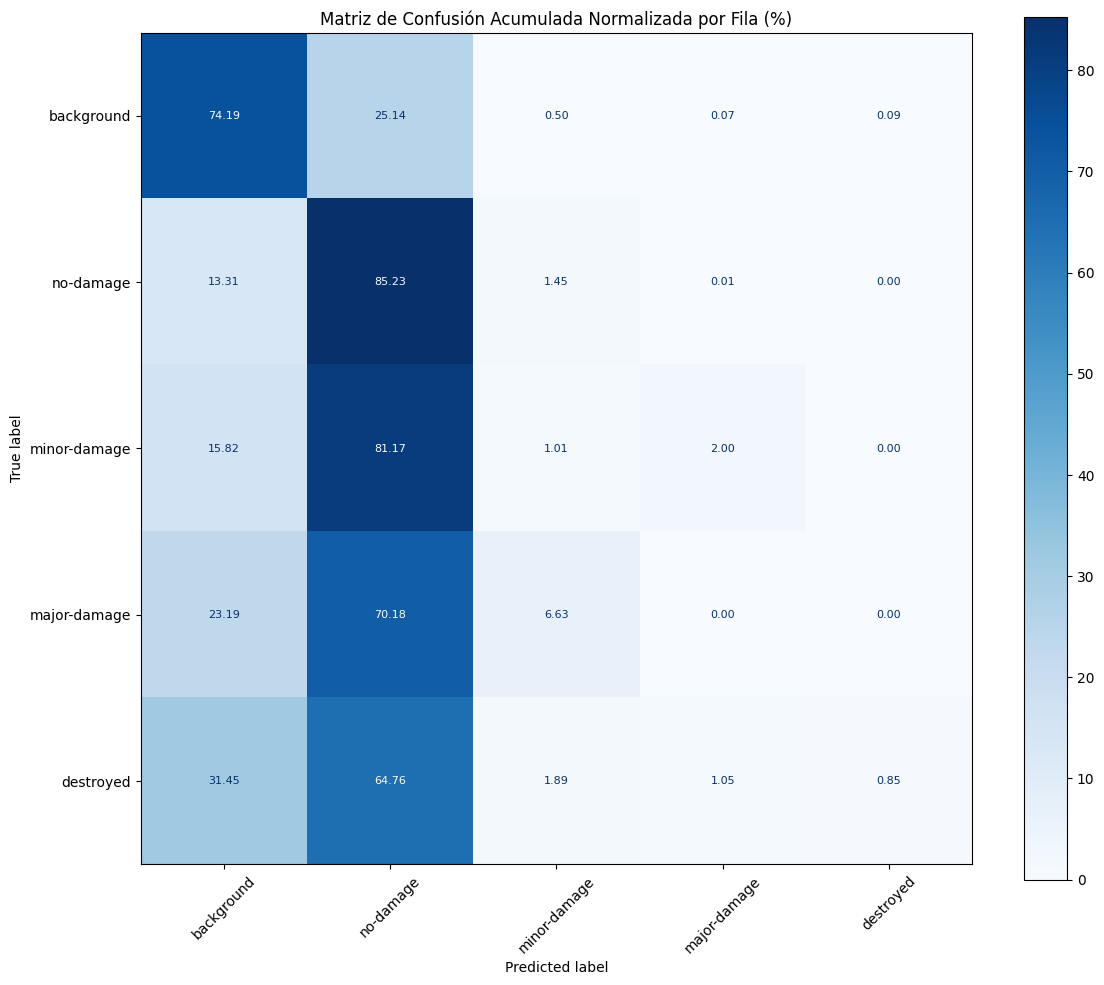

100%|██████████| 63/63 [00:49<00:00,  1.26it/s]

Activation maps saved to /Users/juan.macias@feverup.com/Desktop/cv/cv-2a-image-segmentation/VA_Pr2A_ImageSegmentation_2025_2026/results/parte-4/exp05_deeplabv3_multiclass/activations


In [ ]:
model = get_deeplabv3_r101(num_classes).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# Background ~82% of pixels; no-damage ~12%; minor/major/destroyed ~2% each
# class order: 0=background, 1=no-damage, 2=minor-damage, 3=major-damage, 4=destroyed
# Aggressive upweighting: minor/major/destroyed are ~10-50x rarer than no-damage
alpha     = torch.tensor([1.0, 4.0, 20.0, 30.0, 30.0]).to(device)
criterion = FocalLoss(gamma=2.0, alpha=alpha)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# ReduceLROnPlateau monitors Val Jaccard and only decays when improvement stalls.
# This keeps the LR high while coarse features are learned and reduces it
# later when fine detail (e.g. building borders) is the remaining bottleneck.
lr_sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-7
)
metrics   = {'jaccard_score': jaccard_score}

os.makedirs(result_dir, exist_ok=True)

model = train_model(
    model, criterion, dataloaders, device,
    optimizer, lr_sched, metrics,
    result_dir, model_name,
    num_classes=num_classes, num_epochs=num_epochs,
    aux_weight=0.4,
)

weights = torch.load(os.path.join(result_dir, model_name + '_best.pth.tar'))['state_dict']
model.to(device)
model.load_state_dict(weights)
model.eval()
cm_total = test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, True, batchsize_test)

get_activations(model, dataloaders, device, result_dir, num_classes, class_names)


In [ ]:
def evaluate_per_disaster(model, dataloaders, num_classes, class_names, result_dir, device):
    """Jaccard scores and confusion matrices broken down by disaster category."""
    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import ConfusionMatrixDisplay

    disaster_keywords = ['hurricane', 'earthquake', 'tsunami', 'fire']

    def get_disaster(path):
        name = os.path.basename(path).lower()
        for k in disaster_keywords:
            if k in name:
                return k
        return 'other'

    per_jaccards = {d: [] for d in disaster_keywords}
    per_cm       = {d: np.zeros((num_classes, num_classes), dtype=np.int64)
                    for d in disaster_keywords}

    model.eval()
    with torch.no_grad():
        for sample in tqdm(dataloaders['Test']):
            inputs = sample['image'].to(device)
            masks  = sample['mask']

            _, y_pred = torch.max(torch.softmax(model(inputs)['out'], dim=1), dim=1)
            y_pred = y_pred.cpu().numpy()
            y_true = masks.numpy()

            for j in range(y_pred.shape[0]):
                d = get_disaster(sample['img_path'][j])
                if d not in per_jaccards:
                    continue
                pred_j, true_j = y_pred[j], y_true[j]

                # Jaccard per foreground class (skip class 0 = background)
                ji = []
                for ci in range(1, num_classes):
                    inter = np.logical_and(pred_j == ci, true_j == ci).sum()
                    union = (pred_j == ci).sum() + (true_j == ci).sum() - inter
                    ji.append(inter / union if union > 0 else np.nan)
                per_jaccards[d].append(ji)

                per_cm[d] += confusion_matrix(
                    true_j.ravel(), pred_j.ravel(), labels=list(range(num_classes))
                )

    fg_names = class_names[1:]  # foreground class names (no background)
    n_fg     = len(fg_names)

    mean_ji = {d: np.nanmean(np.array(per_jaccards[d]), axis=0)
               for d in disaster_keywords}

    # ── Plot 1: Grouped bar — Jaccard per class per disaster ─────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    x      = np.arange(n_fg)
    width  = 0.18
    colors = [plt.cm.tab10(i) for i in range(len(disaster_keywords))]

    for i, (d, color) in enumerate(zip(disaster_keywords, colors)):
        offset = (i - (len(disaster_keywords) - 1) / 2) * width
        ax.bar(x + offset, mean_ji[d], width,
               label=f'{d.capitalize()} (n={len(per_jaccards[d])})',
               color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(fg_names, rotation=15)
    ax.set_ylabel('Mean Jaccard')
    ax.set_ylim(0, 1)
    ax.set_title('Jaccard per Damage Class by Disaster Category')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, 'jaccard_per_disaster.png'), dpi=150)
    plt.show()

    # ── Plot 2: Confusion matrix per disaster ─────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for ax, d in zip(axes.ravel(), disaster_keywords):
        cm      = per_cm[d]
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_pct  = np.divide(cm.astype(float), row_sum,
                            out=np.zeros_like(cm, dtype=float),
                            where=row_sum != 0) * 100
        ConfusionMatrixDisplay(
            confusion_matrix=np.round(cm_pct, 1),
            display_labels=class_names
        ).plot(cmap='Blues', values_format='.1f', ax=ax,
               xticks_rotation=45, text_kw={'fontsize': 7})
        ax.set_title(f'{d.capitalize()} (n={len(per_jaccards[d])} images)', fontsize=11)

    plt.suptitle('Confusion Matrices by Disaster Category (%)', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, 'confusion_matrices_per_disaster.png'), dpi=150)
    plt.show()

    return mean_ji, per_cm


mean_ji_disaster, cm_disaster = evaluate_per_disaster(
    model, dataloaders, num_classes, class_names, result_dir, device
)


  0%|          | 0/63 [00:00<?, ?it/s]


RuntimeError: slow_conv2d_forward_mps: input(device='cpu') and weight(device=mps:0')  must be on the same device

### 4.7 Discusión y extensiones propuestas

A continuación se proponen extensiones adicionales al experimento base, siguiendo las sugerencias del enunciado:

#### a) *Data augmentation* para segmentación
Las técnicas de aumento de datos usadas en el primer proyecto también pueden ser útiles aquí. Se pueden considerar transformaciones, como rotaciones, recortes aleatorios o cambios de escala, siempre aplicando la misma transformación a la imagen y a la máscara.

#### b) Modificar la estructura del clasificador de la red (backbone)
Se puede modificar la estructura del clasificador de la red para adecuarlo a la tarea de segmentación con la que se trabaja (muestre especial atención al *receptive field* de la red). Además, se puede utilizar el bloque de clasificación auxiliar de la red (`aux_classifier`), modificando su estructura y añadiendo una función de pérdida para el caso de segmentación multi-clase.

#### c) Funciones de pérdida y estrategias de regularización
A partir de las ideas proporcionadas en el apartado de funciones de pérdida, puede implementar alguna de las estrategias de regularización que se han descrito u otras que considere oportunas. Justifique su utilidad para la tarea que se propone. Recuerde que la base de datos xBD está fuertemente desbalanceada (los píxeles de edificios destruidos son una minoría frente a los intactos o el fondo). Puede evaluar el uso de funciones de coste avanzadas diseñadas para mitigar este problema, como *Focal Loss*, *Dice Loss* o la *Cross-Entropy* ponderada.

#### d) Evaluación por tipo de desastre
El dataset xBD contiene imágenes correspondientes a diferentes desastres naturales (ver carpetas y ficheros en la base de datos). Se puede estratificar la evaluación por tipo de desastre para analizar qué escenarios son más difíciles para el modelo.

__**IMPORTANTE:__ si encuentra problemas para entrenar la red Deeplab-V3 con backbone ResNet-101 o el entrenamiento es demasiado lento y desea agilizar los experimentos, el siguiente fragmento de código implementa Deeplab-V3 con un backbone mucho más ligero, de ResNet-18. Puede utilizarla como red *baseline* para el apartado autónomo. Tenga en cuenta que al no ser una red pre-entrenada en una base de datos para segmentación los resultados serán algo peores, especialmente en las activaciones *atrous* de la red, que visualmente no serán tan claras como en la red tratada.

In [ ]:
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.models.segmentation.fcn import FCNHead
from torchvision.models import resnet18

def get_deeplabv3(num_classes=1):
    model = deeplabv3_resnet101(pretrained=True, progress=True)
    backbone = resnet18(pretrained=True)
    return_layers = {'layer4': 'out'}
    return_layers['layer3'] = 'aux'
    model.backbone = IntermediateLayerGetter(backbone, return_layers=return_layers)
    # Replace stride with dilation in blocks 3 and 4
    model.backbone.layer3[0].conv1.stride=(1,1)
    model.backbone.layer4[0].conv1.stride=(1,1)
    model.backbone.layer3[0].conv1.dilation=(2,2)
    model.backbone.layer3[0].conv1.padding=(2,2)
    model.backbone.layer4[0].conv1.dilation=(4,4)
    model.backbone.layer4[0].conv1.padding=(4,4)
    model.backbone.layer3[0].downsample[0].stride=(1,1)
    model.backbone.layer4[0].downsample[0].stride=(1,1)

    model.classifier = DeepLabHead(512, num_classes)
    model.aux_classifier=FCNHead(256,num_classes)
    return model


## 5. Criterios de evaluación

- Presentación (Fecha indicada en la entrega del proyecto en Aula Global). Este día cada grupo de estudiantes tendrá un turno de 5 minutos de preguntas (máximo 5 minutos de presentación) sobre el apartado de trabajo autónomo con ayuda de un máximo de 5 transparencias.
  
- Informe + código. El grupo de estudiantes entregará un breve informe (5 páginas máximo, incluyendo descripciones, tablas, figuras y referencias) donde describirán los aspectos más importantes de la solución propuesta. El objetivo es que el grupo de estudiantes describa los análisis y extensiones que ha planteado al modelo y justifique su objetivo y utilidad de manera breve. Asimismo, se proporcionará el código utilizado para los experimentos (bien sobre este mismo notebook, en formato `.ipynb` o bien en código Python, en formato `.py`).

La fecha límite de entrega del fichero de código y el informe es la fecha indicada en la entrega del proyecto en Aula Global.